### Practical Work

1. Train a RF on TF-8Bind data. 
2. Predict new sequences with SMW from seed sequence
3. Score unique unssen predicted sequences
4. best sequence == new seed
5. plot how good prediciton is against real world labels


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from split.create_split import create_split
from models.oracle import build_oracle_df, oracle_score_range
from models.single_mutant_walker import SMW
from models.lstm import LSTMSequencePredictor
from models.random_forest import RandomForestPredictor

from models.lstm import train, save_model, load_model

SEED = 42

2026-02-18 15:39:47.449162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)
df.head()

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-5].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in X_train]) # Remove .flatten() for LSTM
X_val_onehot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in X_val]) # Remove .flatten() for LSTM



Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


I0000 00:00:1771425603.533240  252328 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [4]:
lstm = LSTMSequencePredictor(input_size=4, lstm_units=100, dense_units=4, dropout_rate=0.2)
history = train(
    model=lstm,
    X_train = X_train_onehot, 
    y_train = y_train,
     X_val= X_val_onehot,
      y_val = y_val, 
      epochs=2, 
      batch_size=32)

Epoch 1/2 - loss: 0.0058 - val_loss: 0.0053
Epoch 2/2 - loss: 0.0056 - val_loss: 0.0051


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [5]:
save_model(lstm,'lstm_model_TFBind.pt')

In [3]:
# create dataframe for lookup task
test_df = df[df['split'] == 'test_b']
# just use <0.5 binding scores for the oracle
test_df = test_df[test_df['binding_scores'] < 0.5]

df_oracle = build_oracle_df(test_df)

# print highest value and lowest value in oracle
min_score, max_score = oracle_score_range(df_oracle)
print(f'Oracle binding score range: {min_score} - {max_score}')

Oracle binding score range: 0.06085845 - 0.49995875


#### Random Forest

In [ ]:
rf = RandomForestPredictor(seed=SEED)
rf.train(X_train_onehot.reshape(X_train_onehot.shape[0], -1), y_train)
metrics = rf.evaluate(X_val_onehot.reshape(X_val_onehot.shape[0], -1), y_val)
rf.save_model('models/random_forest_TFBind8.pkl')

#### LSTM Model 

In [4]:
model = load_model('lstm_model_TFBind.pt')

### Mutation and Scoring loop
1. One Mutation from Single Mutant Walker
2. Predict with RF
3. Normalize Predicted score to range 0-1
4. If score is higher -> save sequence else continue with old seed
5. Lookup real scores and plot trajectories

In [5]:
from main_scorer import mutate_score_sequences, lookup_oracle, plot_results
# Initialize the Single Mutant Walker
smw = SMW(nucleotides= [0, 1, 2, 3])
n_steps = 200
mutation_steps = 10

# Init rf as scorer
#rf = RandomForestPredictor(seed=SEED)
#scorer = rf #load_model('models/random_forest_TFBind8.pkl')
scorer = model
# Select a random seed sequence from the test set
seed_sequence = X_train[0]
old_score = y_train[0]
print(f"Seed sequence: {seed_sequence}, Score: {old_score:.4f}")
scored_sequences = [i.flatten() for i in X_train_onehot]

# Perform mutation walk
values = mutate_score_sequences(smw, 
                                scorer=scorer,
                                oracle=df_oracle, 
                                seed_sequence=seed_sequence, 
                                score_seed_sequence=old_score, 
                                scored_sequences=scored_sequences, 
                                steps=n_steps, 
                                num_mutations=mutation_steps)

df_values = pd.DataFrame(values)
df_values = lookup_oracle(df_values, df_oracle)

#plot_results(df_values)



Seed sequence: [2 2 1 0 0 1 1 1], Score: 0.2401
Step 2, Mutation 6: New score 0.2745 (improved from 0.2745)
Step 2, Mutation 8: New score 0.3012 (improved from 0.3012)
Step 4, Mutation 2: New score 0.3232 (improved from 0.3232)
Step 4, Mutation 3: New score 0.3307 (improved from 0.3307)
Step 17, Mutation 7: New score 0.3410 (improved from 0.3410)
Step 24, Mutation 7: New score 0.3422 (improved from 0.3422)
Step 25, Mutation 1: New score 0.3460 (improved from 0.3460)
Step 34, Mutation 1: New score 0.3482 (improved from 0.3482)
Step 49, Mutation 1: New score 0.3551 (improved from 0.3551)
Step 59, Mutation 10: New score 0.3595 (improved from 0.3595)
Step 60, Mutation 7: New score 0.3603 (improved from 0.3603)
Step 179, Mutation 8: New score 0.3615 (improved from 0.3615)


Spearman Correlation: 0.4965


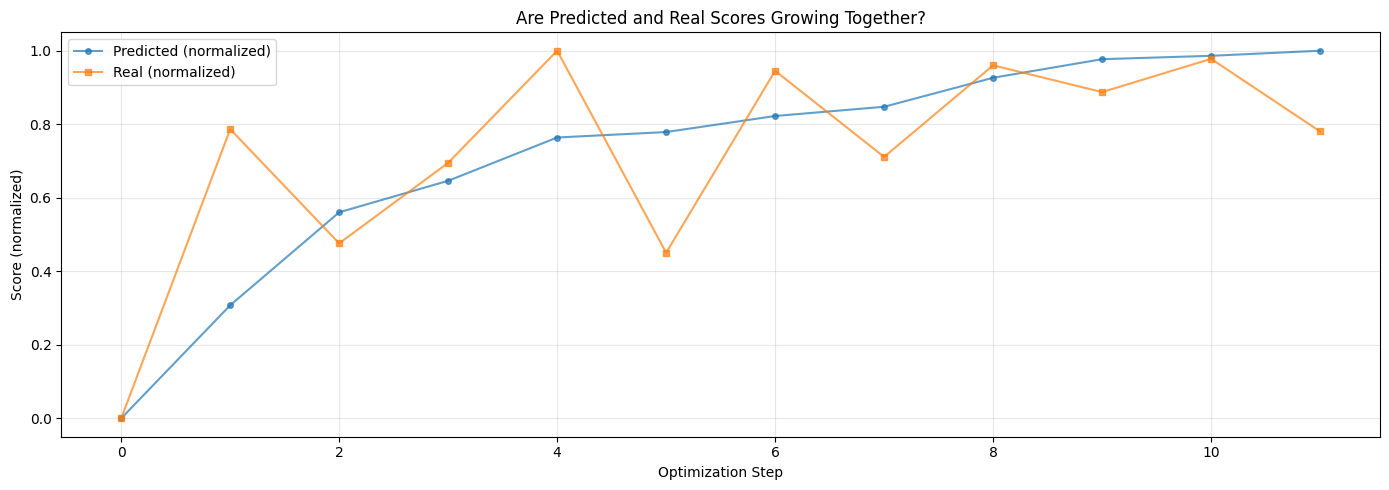

In [6]:
plot_results(df_values)

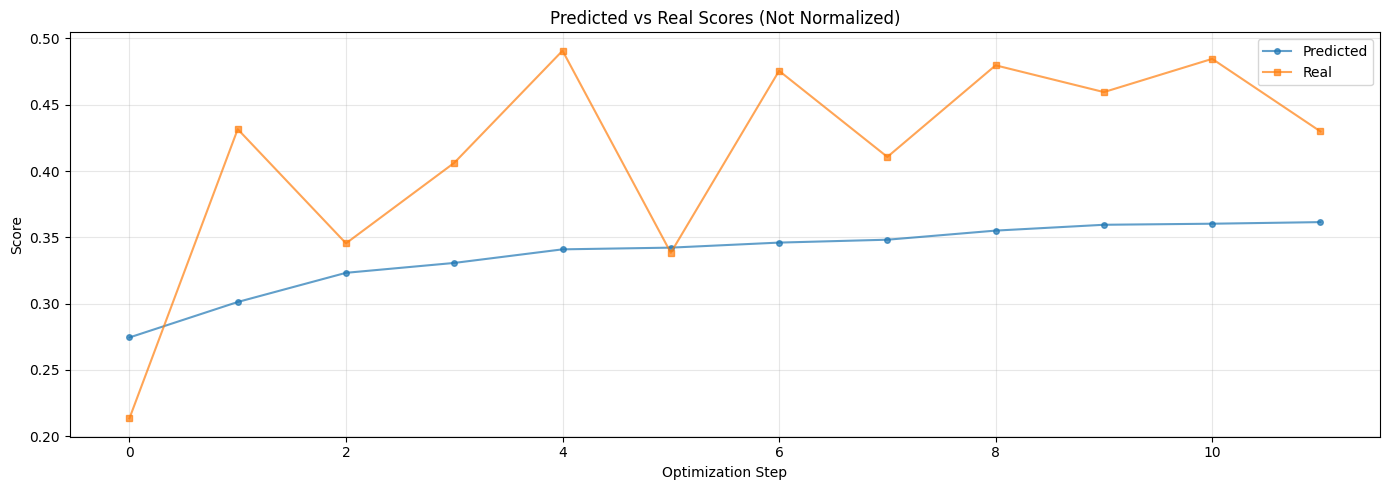

In [7]:
plt.figure(figsize=(14, 5))

# Normalize both to 0-1 range for comparison
pred_norm = (df_values['predicted_score']) # - df_values['predicted_score'].min()) / (df_values['predicted_score'].max() - df_values['predicted_score'].min())
real_norm = (df_values['real_score']) #- df_values['real_score'].min()) / (df_values['real_score'].max() - df_values['real_score'].min())

plt.plot(pred_norm, label='Predicted', marker='o', markersize=4, alpha=0.7)
plt.plot(real_norm, label='Real', marker='s', markersize=4, alpha=0.7)
plt.xlabel('Optimization Step')
plt.ylabel('Score')
plt.title('Predicted vs Real Scores (Not Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
df_values['pred_direction'] = df_values['predicted_score'].diff() > 0
df_values['real_direction'] = df_values['real_score'].diff() > 0
direction_agreement = (df_values['pred_direction'] == df_values['real_direction']).mean()
print(f'Direction agreement: {direction_agreement:.1%}')

Direction agreement: 58.3%


In [ ]:
# save the results to a csv file for further analysis
df_values.to_csv('mutation_walk_results.csv', index=False)

Notes:
1. Testset A: spearman Correlation: 0.683, direction_agreement 66.7%
    Testset A > 0.5: spearman: 0.476, direction: 58.3%
    Testset A < 0.5: spearman: 0.413, direction: 58.3%
2. Testset B: spearman Correlation: 0.524, direction_agreement 58.3%
    Testset B > 0.5: spearman: 0.817 , direction: 55.6%
    Testset B < 0.5: spearman: -0.095, direction: 75.0%
3. Testset C: spearman Correlation: 0.764, direction_agreement 72.7


LSTM:
Testset A: spearman: 0.321, direction 57.1%
Testset B: spearman: 0.915, direction 70%
Testset C: spearman: 0.433, direction 57.1% 

In [ ]:
# Scatter plot shows correlation regardless of absolute values
plt.figure(figsize=(8, 8))
plt.scatter(df_values['real_score'], df_values['predicted_score'], alpha=0.5)
plt.plot([df_values['real_score'].min(), df_values['real_score'].max()], 
         [df_values['real_score'].min(), df_values['real_score'].max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Real Binding Score')
plt.ylabel('Predicted Binding Score')
plt.title('Predicted vs Real Binding Scores')
plt.legend()

# Add Spearman correlation to plot
from scipy.stats import spearmanr
corr, _ = spearmanr(df_values['real_score'], df_values['predicted_score'])
plt.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.tight_layout()
plt.show()

### Plot the trajcectories into a Scatterplot

/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_252328/685193560.py:62: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1],
/tmp/ipykernel_252328/685193560.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


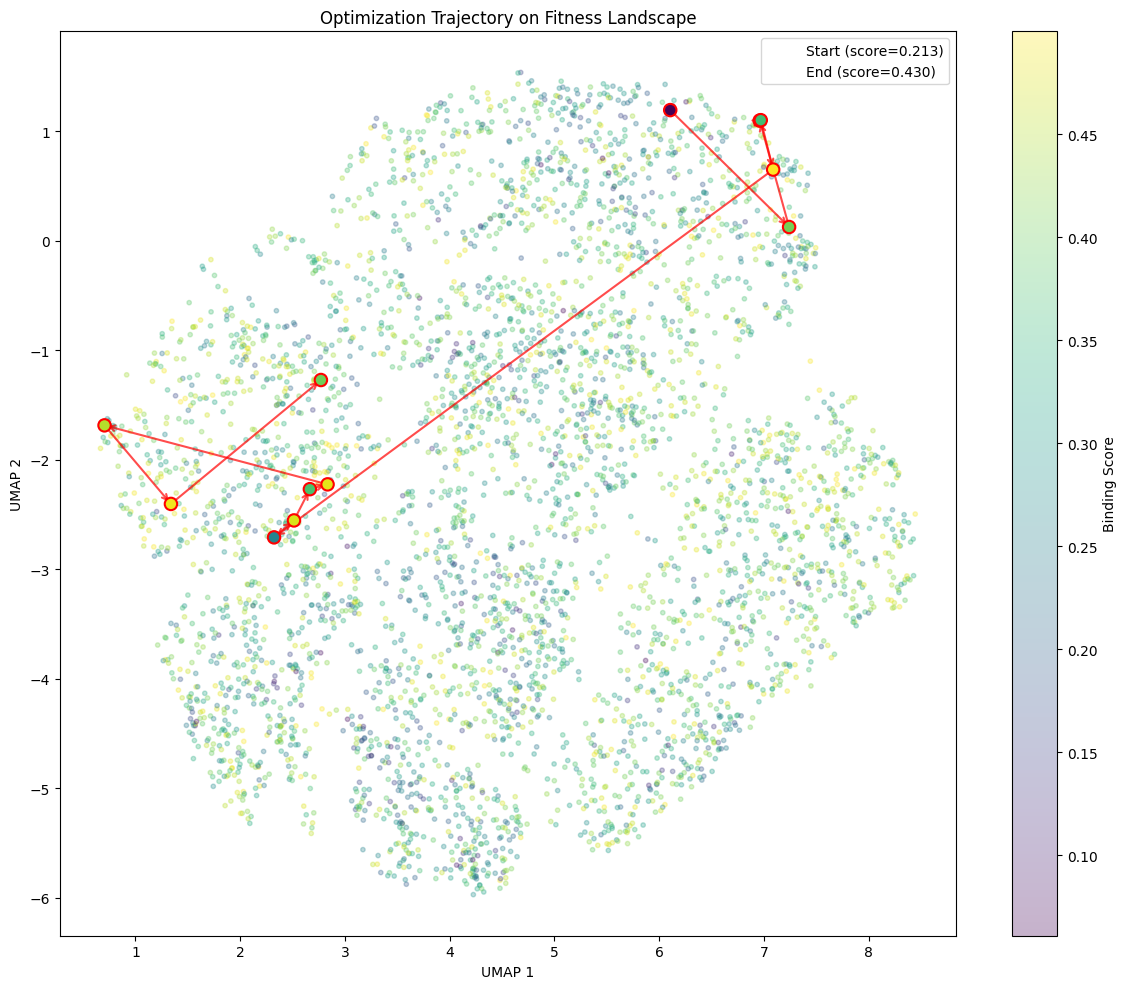

In [9]:
from matplotlib.patches import FancyArrowPatch
import umap
from sklearn.preprocessing import StandardScaler

# Prepare all sequences for embedding (oracle + trajectory)
X_oracle_onehot = np.vstack(df_oracle['one_hot_seq'].values)
X_trajectory = np.vstack(df_values['mutation'].values)

# Combine for consistent embedding
X_combined = np.vstack([X_oracle_onehot, X_trajectory])

# Fit UMAP on combined data
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Split back
n_oracle = len(X_oracle_onehot)
embedding_oracle = embedding[:n_oracle]
embedding_trajectory = embedding[n_oracle:]

# Get scores for coloring
oracle_scores = df_oracle['binding_scores'].values
trajectory_real_scores = df_values['real_score'].values


fig, ax = plt.subplots(figsize=(12, 10))


# Background landscape
scatter = ax.scatter(
    embedding_oracle[:, 0], 
    embedding_oracle[:, 1], 
    c=oracle_scores, 
    cmap='viridis', 
    alpha=0.3, 
    s=10
)
plt.colorbar(scatter, label='Binding Score')

# Draw arrows between consecutive trajectory points
for i in range(len(embedding_trajectory) - 1):
    ax.annotate(
        '', 
        xy=(embedding_trajectory[i+1, 0], embedding_trajectory[i+1, 1]),
        xytext=(embedding_trajectory[i, 0], embedding_trajectory[i, 1]),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7)
    )

# Trajectory points colored by score
ax.scatter(
    embedding_trajectory[:, 0], 
    embedding_trajectory[:, 1], 
    c=trajectory_real_scores,
    cmap='viridis',
    edgecolors='red',
    linewidths=1.5,
    s=80,
    zorder=5
)

# Start and end markers
ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1], 
           c='lime', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'Start (score={trajectory_real_scores[0]:.3f})', zorder=10)
ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1], 
           c='red', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'End (score={trajectory_real_scores[-1]:.3f})', zorder=10)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Optimization Trajectory on Fitness Landscape')
ax.legend(loc='upper right')
plt.tight_layout()
#plt.savefig('LSTM_fitness_landscape_trajectory_testset_b.png', dpi=150)
plt.show()